In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from IPython.core.debugger import set_trace
import random
import math


np.random.seed(59)
sns.set_theme(style="ticks", context="poster", font_scale=1.4)

from conformal_tree import ConformalTreeClassification
from demo_util import gen_sin_data, split_conformal

ALPHA_RANGE = np.arange(0.01,0.25,0.01)
M = 50 #20 #400#200#100 #40
MAX_DEPTH = 24
MAX_LEAVES = 60

TEST_SIZE= 0.4 #0.2 #0.8#0.2#0.5

N= int(366 *(1-TEST_SIZE))

def delta_giver(m): 
    return 2/m +  math.comb(N+1, m) * ((m/(N+1))**m) * (1-(m/(N+1)))**(N+1-m)

DELTA = delta_giver(M) 
print(DELTA)

0.10406779024595747


# Example data

We demonstrate conformal tree for classification on the dermatology data example

The data is taken from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/33/dermatology)

In [25]:
data_path = './data/dermatology.data'
df = pd.read_csv(data_path, header=None)

columns = [
    'erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon', 'polygonal_papules',
    'follicular_papules', 'oral_mucosal_involvement', 'knee_and_elbow_involvement', 'scalp_involvement',
    'family_history', 'melanin_incontinence', 'eosinophils_in_the_infiltrate', 'PNL_infiltrate',
    'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis', 'hyperkeratosis', 'parakeratosis',
    'clubbing_of_the_rete_ridges', 'elongation_of_the_rete_ridges', 'thinning_of_the_suprapapillary_epidermis',
    'spongiform_pustule', 'munro_microabcess', 'focal_hypergranulosis', 'disappearance_of_the_granular_layer',
    'vacuolisation_and_damage_of_basal_layer', 'spongiosis', 'saw-tooth_appearance_of_retes',
    'follicular_horn_plug', 'perifollicular_parakeratosis', 'inflammatory_monoluclear_inflitrate',
    'band-like_infiltrate', 'age', 'class'
]

df.columns = columns

df.replace('?', pd.NA, inplace=True)
df['age'] = pd.to_numeric(df['age'], errors='coerce')

mean_age = df['age'].mean()
df['age'] = df['age'].fillna(mean_age)

df



,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25.0,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36.0,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28.0,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50.0,3


The data contains clinical features, which are observed by a practitioner in a clinical setting, as well as histopathological features, which are studied through blood samples. In this case, we restrict to only clinical features, and try to predict the class of disease from 6 possibilities

In [26]:
feature_columns = [
    'erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon', 'polygonal_papules',
    'follicular_papules', 'oral_mucosal_involvement', 'knee_and_elbow_involvement', 'scalp_involvement',
    'family_history', 'age'
]
clinical_vals = df[feature_columns].values
clinical_labels = df["class"].values
clinical_labels

array([2, 1, 3, 1, 3, 2, 5, 3, 4, 4, 1, 2, 2, 1, 3, 4, 2, 1, 3, 5, 6, 2,
       5, 3, 5, 1, 6, 5, 2, 3, 1, 2, 1, 1, 4, 2, 3, 2, 3, 1, 2, 4, 1, 2,
       5, 3, 4, 6, 2, 3, 3, 4, 1, 1, 5, 1, 2, 3, 4, 2, 6, 1, 5, 1, 2, 3,
       1, 4, 5, 1, 2, 6, 3, 5, 4, 2, 2, 1, 3, 5, 1, 2, 2, 2, 5, 1, 1, 3,
       1, 4, 2, 2, 5, 1, 3, 4, 2, 5, 1, 6, 2, 5, 1, 2, 2, 1, 4, 1, 3, 1,
       1, 3, 5, 3, 3, 5, 2, 3, 4, 1, 2, 5, 6, 1, 1, 2, 6, 3, 5, 4, 1, 1,
       3, 5, 5, 1, 4, 2, 3, 1, 2, 1, 1, 3, 3, 3, 2, 5, 4, 2, 2, 1, 1, 1,
       5, 3, 2, 3, 2, 2, 4, 2, 3, 6, 2, 1, 1, 3, 4, 3, 3, 1, 1, 1, 3, 1,
       1, 2, 3, 3, 1, 1, 1, 1, 6, 2, 2, 2, 2, 1, 3, 3, 3, 1, 1, 2, 3, 2,
       2, 2, 5, 5, 5, 5, 5, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 4, 4,
       4, 4, 5, 5, 5, 5, 5, 5, 5, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 6, 6, 1,
       1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5,
       5, 5, 6, 6, 6, 4, 4, 4, 1, 1, 1, 1, 1, 2, 2, 4, 4, 4, 1, 1, 2, 2,
       2, 3, 3, 3, 3, 1, 1, 1, 1, 5, 5, 5, 5, 5, 3,

In this case, the black-box model is using an LLM (GPT-4) to classify the disease based on clinical features. For this demonstration, we provide the response data for each observation in the dermatology dataset. For each sample, GPT assigned probabilities to the six classes. This data is stored as dictionaries in `data/dermdata.json`.

In [27]:
import json
with open("./data/dermdata.json", "r") as f:
    output_data_ = json.load(f)
    #output_data = json.load(f)
#print(output_data_[0])
#output_data[0]

labs_strs = {
    "psoriasis":1,
    "seboreic dermatitis":2,
    "lichen planus":3,
    "pityriasis rosea":4,
    "cronic dermatitis":5,
    "pityriasis rubra pilaris":6
}
output_data= []
random.seed(42)
for prd in output_data_:
    perturbed = {labs_strs[key]:value+random.uniform(0.0001, 0.001) for key, value in prd.items()}
    Z = sum(list(perturbed.values()))
    normalized = {key: (value/Z) for key, value in perturbed.items()}
    output_data.append(normalized)
#output_data
#output_data
#prd.items()

Here is an example of what the predictions for the first sample look like

## Next plot

In [28]:
alpha=0.1
TEST_SIZE = 0.2
M = 10
MAX_LEAVES = 20

n = len(clinical_vals)
indices = np.arange(0, n)

In [29]:
def conformal_set(test_idx, conf_quant):
    probs = output_data[test_idx]
    #set_trace()
    nonconformity_scores = {label: 1 - prob for label, prob in probs.items()}
    filtered_scores = {label: score for label, score in nonconformity_scores.items() if score <= conf_quant}
    #set_trace()
    return list(filtered_scores.keys())

In [30]:
def score_giver(calib_idx):
    conf_scores = []

    for idx in calib_idx: 
        true_label = clinical_labels[idx]
        sp = output_data[idx]
        conf = 1.0 - float(sp[true_label])
        conf_scores.append(conf)

    conf_scores = np.array(conf_scores)
    return np.array(conf_scores)

In [31]:
def conformal_sets(calib_idx, test_idx, alpha = 0.1):
    
    conf_scores = score_giver(calib_idx)
    n = len(calib_idx)
    conf_quant = np.quantile(conf_scores, min(1,np.ceil((1 - alpha)*(n+1))/n))

    test_conformal_sets = []
    for i,tidx in enumerate(test_idx):
        #set_trace()
        test_pt = clinical_vals[tidx]

        test_conformal_sets.append(conformal_set(tidx, conf_quant))
    return test_conformal_sets

In [32]:

def naive_set(test_idx, alpha = 0.1):
    test_naive_sets = []
    for idx in test_idx: 
        sp = output_data[idx]
        
        sorted_keys = sorted(sp.keys(), key=lambda k: sp[k], reverse=True)

        # Select keys until the cumulative sum exceeds 0.9
        selected_keys = set()
        cumulative_sum = 0

        for key in sorted_keys:
            cumulative_sum += sp[key]
            selected_keys.add(key)
            if cumulative_sum > 1-alpha:
                break
                
        test_naive_sets.append(list(selected_keys))
    return test_naive_sets

In [33]:
def tree_sets(calib_idx, test_idx, alpha = 0.1, ):
    conf_scores = score_giver(calib_idx)
    domain = np.array([[-1.0,4.0],[-1.0,4.0],[-1.0,4.0],[-1.0,4.0],[-1.0,4.0],
                       [-1.0,4.0],[-1.0,4.0],[-1.0,4.0],[-1.0,4.0],[-1.0,4.0],
                       [-1.0,2.0], [0.0,100.0]])

    ctrc = ConformalTreeClassification(domain=domain,
                                       min_samples_leaf=M, 
                                       max_depth=MAX_DEPTH, 
                                       max_leaves=MAX_LEAVES)
    ctrc.calibrate(clinical_vals[calib_idx], conf_scores, alpha=alpha)

    test_tree_sets, return_group_indices = ctrc.test_set(clinical_vals[test_idx], 
                                           y_test_pred=np.array(output_data)[test_idx], 
                                           return_group_idx=True)
    test_tree_sets = ctrc.test_set(clinical_vals[test_idx], y_test_pred=np.array(output_data)[test_idx])
    return test_tree_sets

In [34]:
def state_wise_efficiency(the_id):
    subset_idxs = true_labels[test_idx] == the_id

    test_tree_set_sizes_state = [len(l) for i,l in enumerate(test_tree_sets) if subset_idxs[i]==True]
    test_cp_set_sizes_state = [len(l) for i,l in enumerate(test_conformal_sets) if subset_idxs[i] == True]
    test_naive_set_sizes_state = [len(l) for i,l in enumerate(test_naive_sets) if subset_idxs[i] == True]
    return np.mean(test_tree_set_sizes_state), np.mean(test_cp_set_sizes_state), np.mean(test_naive_set_sizes_state) 




In [35]:
labs_strs = {
    1: "psoriasis",
    2: "seboreic dermatitis",
    3: "lichen planus",
    4: "pityriasis rosea",
    5: "cronic dermatitis",
    6: "pityriasis rubra pilaris"
}

In [36]:
true_labels = df["class"].values

In [37]:
calib_idx, test_idx = train_test_split(indices, test_size=TEST_SIZE, random_state=42)

test_conformal_sets = conformal_sets(calib_idx, test_idx)
test_naive_sets = naive_set(test_idx)
test_tree_sets = tree_sets(calib_idx, test_idx)

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

effs = { v: state_wise_efficiency(k) for k,v in labs_strs.items()}

In [39]:
dfv = pd.DataFrame(effs, index=['Conformal \nTree', 'Split \nConformal', "Naive UQ"]).T
dfv = dfv.round(2)
dfv

,Conformal \nTree,Split \nConformal,Naive UQ
psoriasis,1.58,2.52,4.87
seboreic dermatitis,3.44,3.33,4.89
lichen planus,1.92,3.92,5.31
pityriasis rosea,4.12,4.00,5.12
cronic dermatitis,4.20,4.10,5.20
pityriasis rubra pilaris,6.00,4.00,5.33


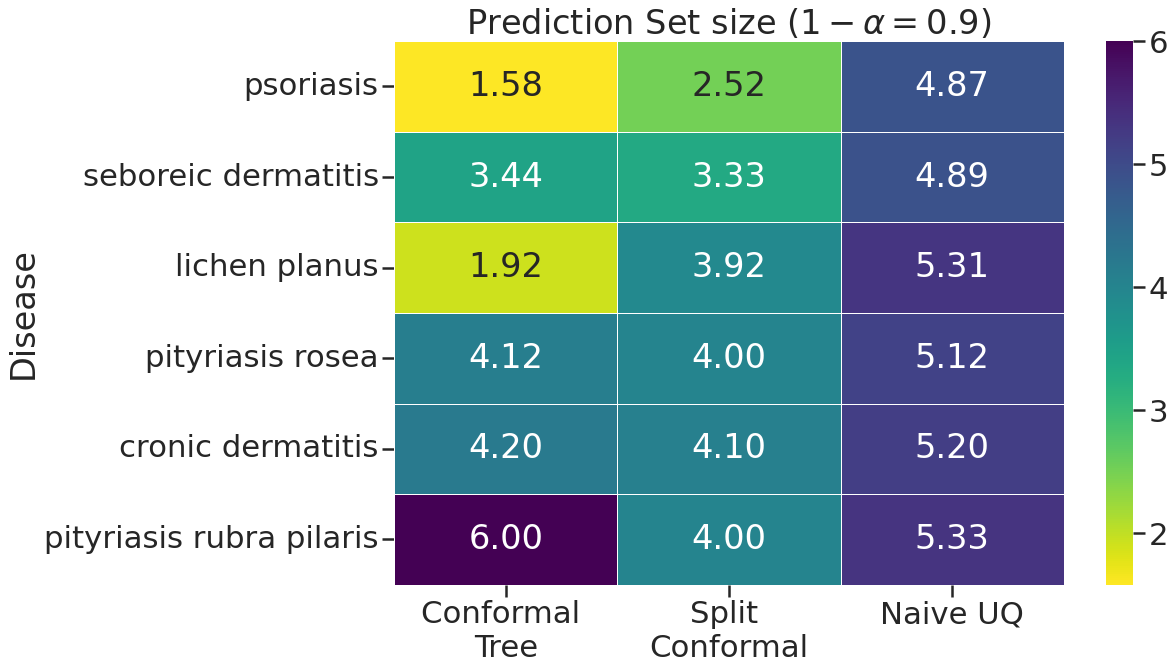

In [40]:
plt.figure(figsize=(15, 10))
ax = sns.heatmap(dfv, annot=True, cmap='viridis_r', cbar=True, linewidths=.5, fmt=".2f")
ax.set_title(r'Prediction Set size ($1-\alpha=0.9$)')
#plt.xlabel('Method')
plt.ylabel('Disease')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

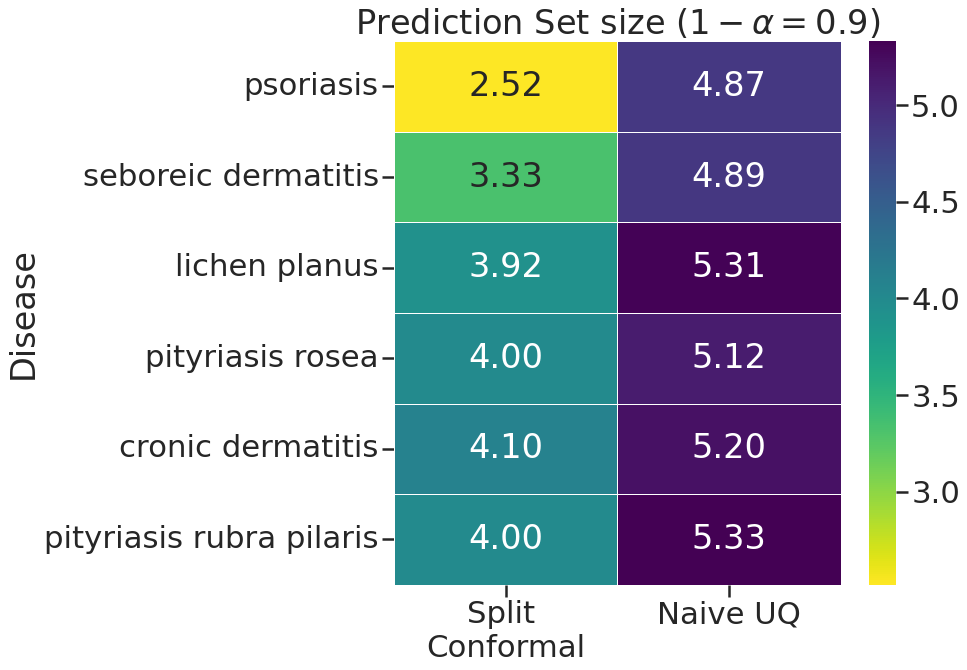

In [41]:
dfv = pd.DataFrame(effs, index=['Conformal \nTree', 'Split \nConformal', "Naive UQ"]).T
dfv = dfv.round(2)
dfv = dfv[['Split \nConformal', "Naive UQ"]]

plt.figure(figsize=(10, 10))
ax = sns.heatmap(dfv, annot=True, cmap='viridis_r', cbar=True, linewidths=.5, fmt=".2f")
ax.set_title(r'Prediction Set size ($1-\alpha=0.9$)')
#plt.xlabel('Method')
plt.ylabel('Disease')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

In [42]:
n = len(df)
indices = np.arange(0, n)
calib_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=12345)

y_calib_pred = np.array(output_data)[calib_idx]
y_test_pred = np.array(output_data)[test_idx]

X_calib = clinical_vals[calib_idx]
y_calib = clinical_labels[calib_idx]
X_test = clinical_vals[test_idx]
y_test = clinical_labels[test_idx]

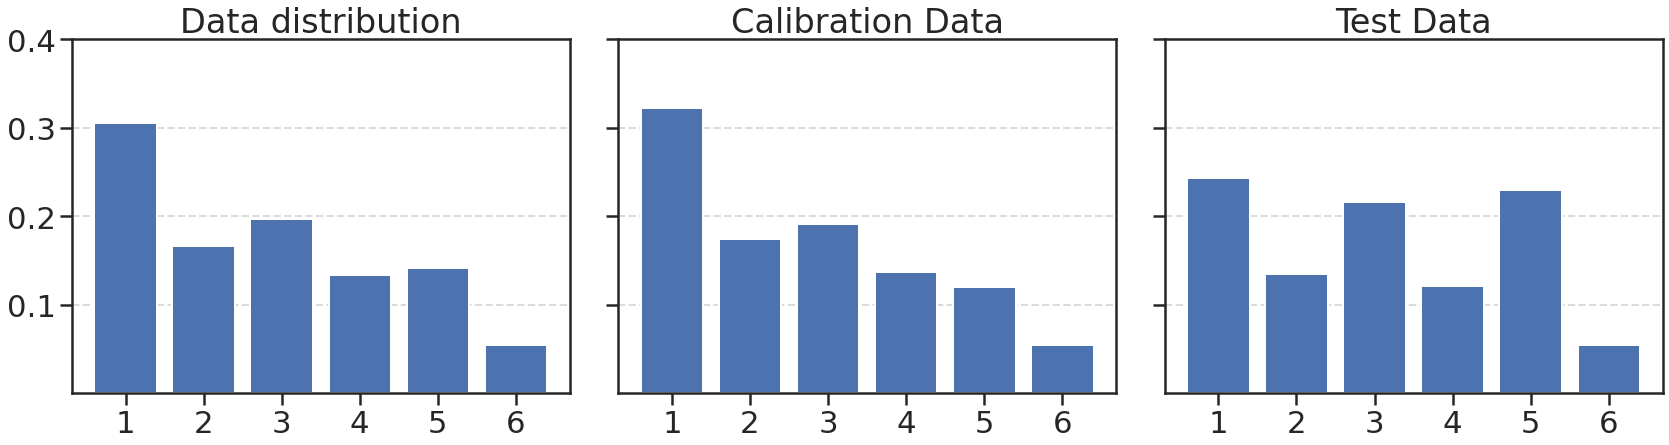

In [84]:
u1, indices1 = np.unique(clinical_labels, return_counts=True)
u2, indices2 = np.unique(y_calib, return_counts=True)
u3, indices3 = np.unique(y_test, return_counts=True)

# Normalize counts
freq1 = indices1 / (292 + 74)
freq2 = indices2 / 292
freq3 = indices3 / 74

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

# Plot each distribution
axes[0].bar(u1, freq1)
axes[1].bar(u2, freq2)
axes[2].bar(u3, freq3)

# Set titles
axes[0].set_title("Data distribution")
axes[1].set_title("Calibration Data")
axes[2].set_title("Test Data")

# Set common labels
for ax in axes:
    #ax.set_xlabel("Value")
    ax.set_xticks(np.arange(1, 7))  # Adjust as needed
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_yticks([0.1, 0.2, 0.3, 0.4])  # Explicit grid levels

#axes[0].set_ylabel("Proportion")

# Show the plot
plt.tight_layout()
plt.show()


In [44]:
list_of_dfvs = []
for _ in range (30):
    seed = random.randint(1,100000)
    
    calib_idx, test_idx = train_test_split(indices, test_size=TEST_SIZE, random_state=seed)
    test_conformal_sets = conformal_sets(calib_idx, test_idx)
    test_naive_sets = naive_set(test_idx)
    test_tree_sets = tree_sets(calib_idx, test_idx)

    effs = { v: state_wise_efficiency(k) for k,v in labs_strs.items()}
    dfv = pd.DataFrame(effs, index=['Conformal \nTree', 'Split \nConformal', "Naive UQ"]).T
    dfv = dfv.round(2)
    list_of_dfvs.append(dfv)

In [45]:
df_mean = pd.concat(list_of_dfvs).groupby(level=0).mean()
y_order = [
    "psoriasis",
    "seboreic dermatitis",
    "lichen planus",
    "pityriasis rosea",
    "cronic dermatitis",
    "pityriasis rubra pilaris"
]
df_mean = df_mean.loc[y_order]

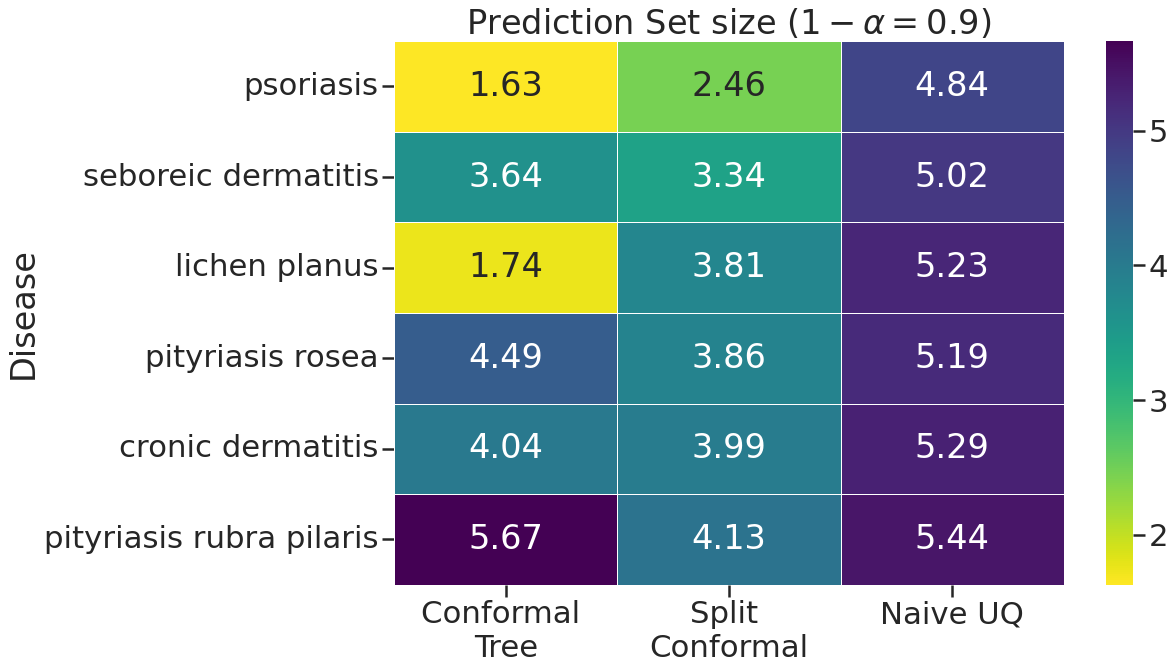

In [46]:

plt.figure(figsize=(15, 10))
ax = sns.heatmap(df_mean, annot=True, cmap='viridis_r', cbar=True, linewidths=.5, fmt=".2f")
ax.set_title(r'Prediction Set size ($1-\alpha=0.9$)')
#plt.xlabel('Method')
plt.ylabel('Disease')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

In [49]:
output_data

[{1: 0.24994607561402665,
  2: 0.29924922160469136,
  3: 0.05020102656402145,
  4: 0.10000903694408934,
  5: 0.2500331614487511,
  6: 0.0505614778244201},
 {1: 0.6991276335102249,
  2: 0.09992450190206988,
  3: 0.050351868739060994,
  4: 0.049999850495531684,
  5: 0.050169376689421626,
  6: 0.05042676866369102},
 {1: 0.09986354656922619,
  2: 0.050148221721141105,
  3: 0.5991230330164918,
  4: 0.050458905242453216,
  5: 0.10003760699556571,
  6: 0.10036868645512195},
 {1: 0.6986389138672064,
  2: 0.09979309173665778,
  3: 0.05066644584341647,
  4: 0.050569836750572285,
  5: 0.05024874308550603,
  6: 0.05008296871664101},
 {1: 0.2501507428981103,
  2: 0.14991704776046985,
  3: 0.19953676438242487,
  4: 0.09986338339801508,
  5: 0.20021384361141073,
  6: 0.10031821794956906},
 {1: 0.5983259508475894,
  2: 0.199921267433077,
  3: 0.05037209520726995,
  4: 0.050763657733186196,
  5: 0.05023076151223893,
  6: 0.050386267266638696},
 {1: 0.20007145904830737,
  2: 0.24968946026832378,
  3: 0.

In [50]:
clinical_labels

array([2, 1, 3, 1, 3, 2, 5, 3, 4, 4, 1, 2, 2, 1, 3, 4, 2, 1, 3, 5, 6, 2,
       5, 3, 5, 1, 6, 5, 2, 3, 1, 2, 1, 1, 4, 2, 3, 2, 3, 1, 2, 4, 1, 2,
       5, 3, 4, 6, 2, 3, 3, 4, 1, 1, 5, 1, 2, 3, 4, 2, 6, 1, 5, 1, 2, 3,
       1, 4, 5, 1, 2, 6, 3, 5, 4, 2, 2, 1, 3, 5, 1, 2, 2, 2, 5, 1, 1, 3,
       1, 4, 2, 2, 5, 1, 3, 4, 2, 5, 1, 6, 2, 5, 1, 2, 2, 1, 4, 1, 3, 1,
       1, 3, 5, 3, 3, 5, 2, 3, 4, 1, 2, 5, 6, 1, 1, 2, 6, 3, 5, 4, 1, 1,
       3, 5, 5, 1, 4, 2, 3, 1, 2, 1, 1, 3, 3, 3, 2, 5, 4, 2, 2, 1, 1, 1,
       5, 3, 2, 3, 2, 2, 4, 2, 3, 6, 2, 1, 1, 3, 4, 3, 3, 1, 1, 1, 3, 1,
       1, 2, 3, 3, 1, 1, 1, 1, 6, 2, 2, 2, 2, 1, 3, 3, 3, 1, 1, 2, 3, 2,
       2, 2, 5, 5, 5, 5, 5, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 4, 4,
       4, 4, 5, 5, 5, 5, 5, 5, 5, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 6, 6, 1,
       1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5,
       5, 5, 6, 6, 6, 4, 4, 4, 1, 1, 1, 1, 1, 2, 2, 4, 4, 4, 1, 1, 2, 2,
       2, 3, 3, 3, 3, 1, 1, 1, 1, 5, 5, 5, 5, 5, 3,

In [54]:
p_hat_y = {k:[] for k in range(1,7)}

for i in range(len(output_data)):
    sp=output_data[i]
    true_label = clinical_labels[i]
    p_hat_y[true_label].append(sp[true_label])

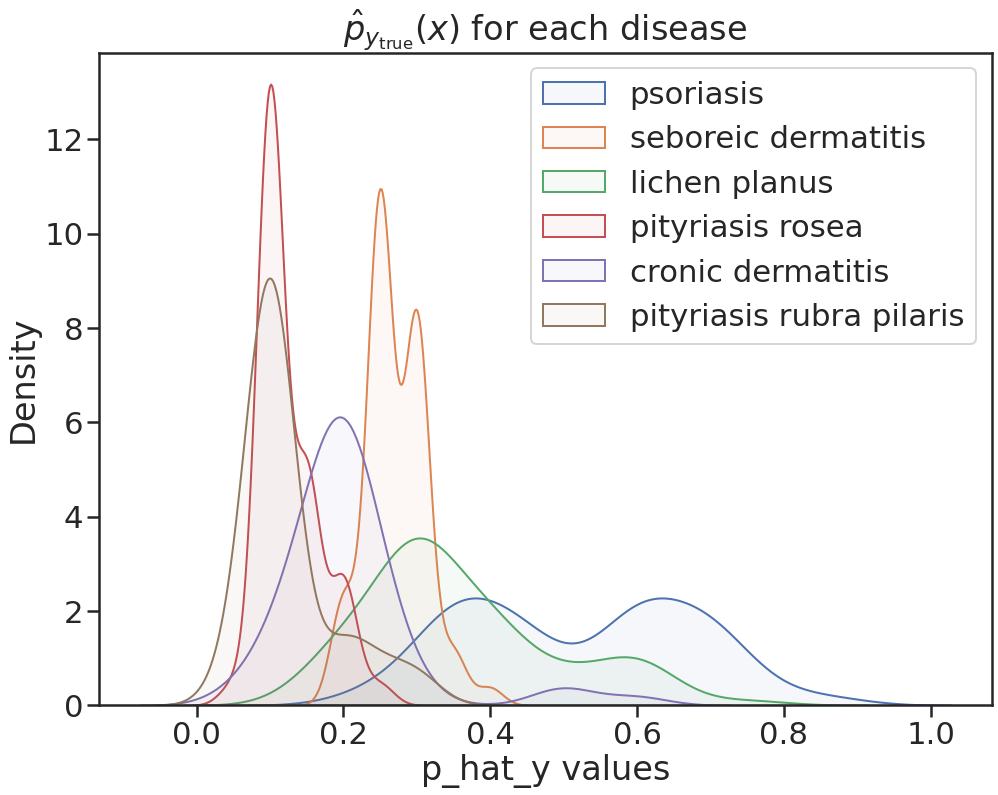

In [63]:
# Create a density plot for each label in range(1,7)
plt.figure(figsize=(16, 12))

for k in range(1, 7):
    sns.kdeplot(p_hat_y[k], label=y_order[k-1], fill=True, alpha=0.05)

# Labels and legend
plt.xlabel('p_hat_y values')
plt.ylabel('Density')
plt.title(r'$\hat{p}_{y_{\rm true}}(x)$ for each disease')
plt.legend()

# Show the plot
plt.show()

In [68]:
Accurated= {k:[] for k in range(1,7)}

for i in range(len(output_data)):
    sp=output_data[i]
    true_label = clinical_labels[i]
    predicted_label = max(sp, key=sp.get)
    
    Accurated[true_label].append( true_label == predicted_label)

In [74]:
performance = {key: np.mean(accus) for key, accus in Accurated.items()}

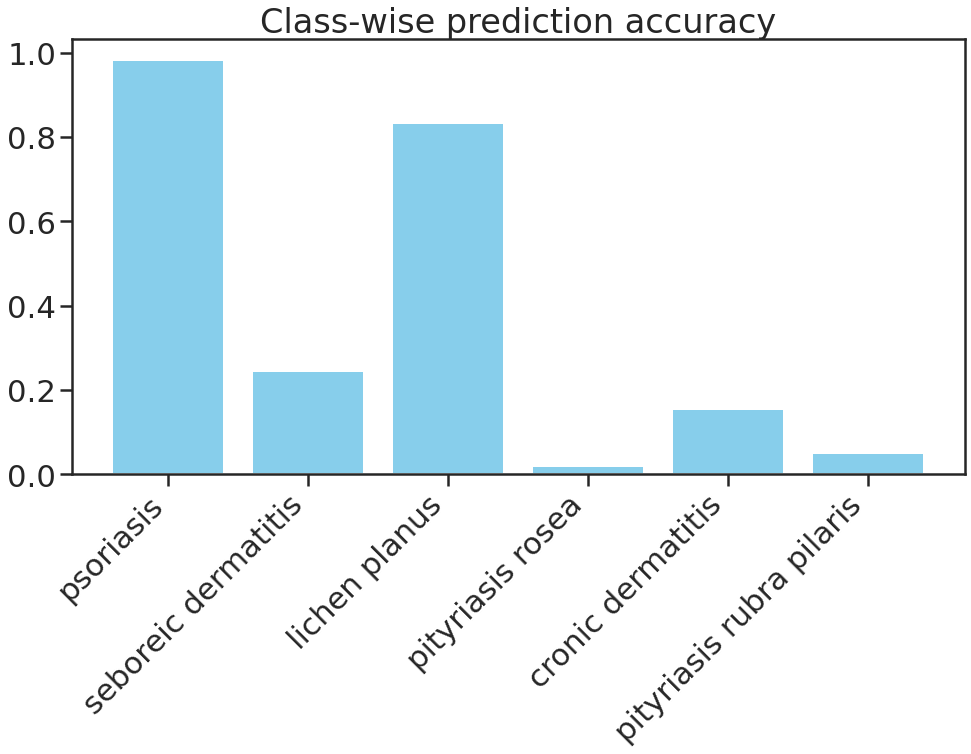

In [80]:
# Create bar plot
plt.figure(figsize=(16, 8))
#plt.bar(performance.keys(), performance.values(), color='skyblue')
plt.bar(y_order, performance.values(), color='skyblue')


# Labels and title

plt.title("Class-wise prediction accuracy")
#plt.xticks(list(performance.keys()))
plt.xticks(rotation=45, ha="right")
# Show plot
plt.show()